In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# Create synthetic Customer Churn Data
X, y = make_classification(n_samples=1200, n_features=6, n_informative=4, n_redundant=1, n_clusters_per_class=2, flip_y=0.03, random_state=42)

In [3]:
# Convert it into a df
df = pd.DataFrame(X, columns=[
    "Monthly_Charges", "Tenure", "Service_Calls", "Contract_Length", "Payment_Delays", "Internet_Usage"
])
df["Churn"] = y

In [4]:
df.head()

,Monthly_Charges,Tenure,Service_Calls,Contract_Length,Payment_Delays,Internet_Usage,Churn
0,1.284795,0.897990,-0.224510,1.411368,-1.651779,1.798861,1
1,1.559938,-1.702022,-1.931215,-1.712366,1.592794,-0.472072,1
2,0.380259,0.277720,1.144874,1.514255,0.586134,0.325751,1
3,0.116562,-0.742467,-0.275148,-1.073542,0.834975,-1.021280,1
4,0.255626,0.239967,0.584774,2.066564,-1.957585,0.930315,1


<Figure size 1000x800 with 0 Axes>

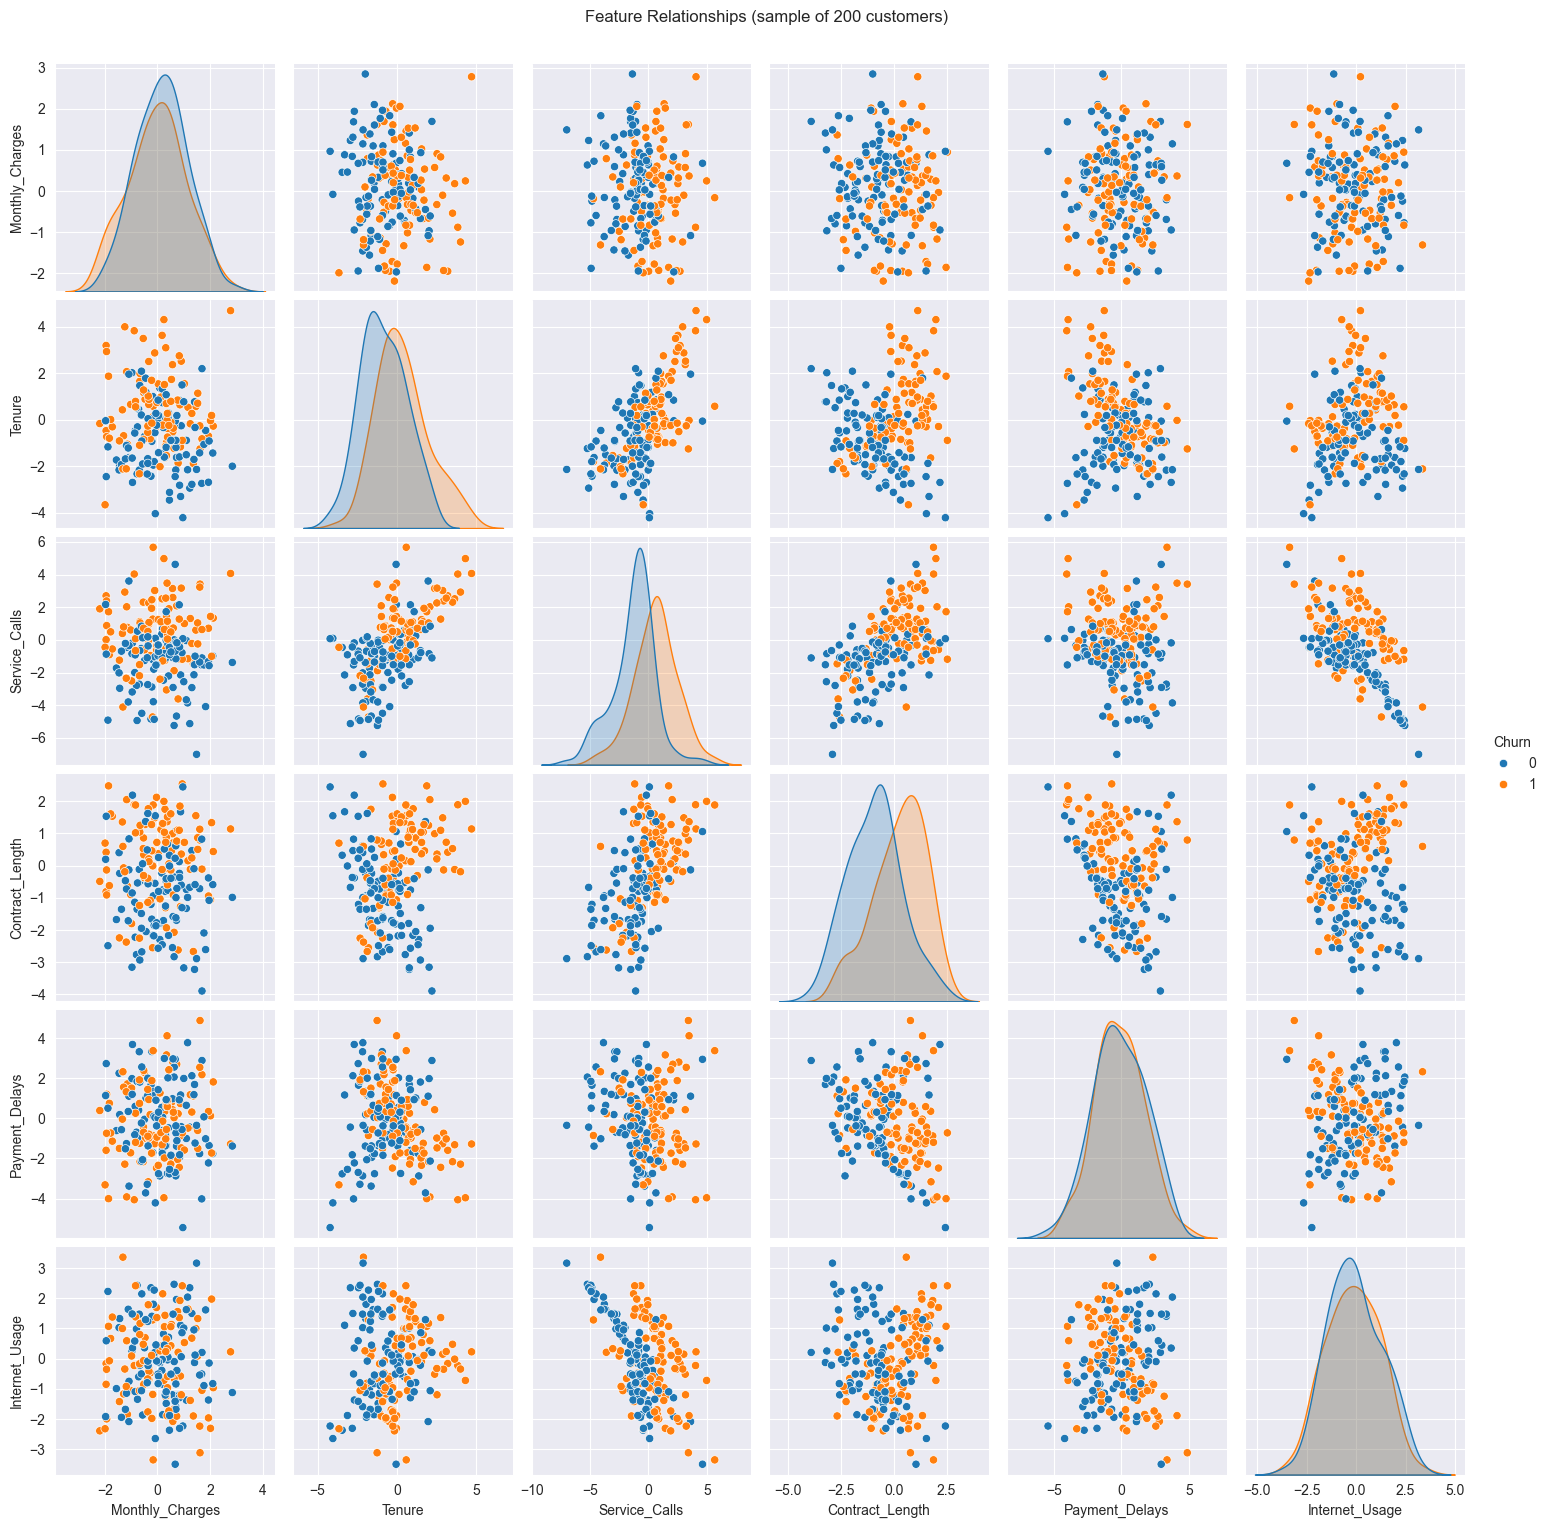

In [5]:
# Visualize relationships
plt.figure(figsize=(10, 8))

# Randomly select 200 samples
sns.pairplot(df.sample(200), hue="Churn", diag_kind="kde")
plt.suptitle("Feature Relationships (sample of 200 customers)", y = 1.02)
plt.show()


# Interpreting the pairplot

# Diagonal (KDE plots) --> Each diagonal plot shows the density curve of a single feature, separated by class
# If the two curves are well-separated, that feature is a strong predictor
# If they overlap, that feature doesnt distinguish the classes really well
# Example: If tenure has two separated curves, churned customers tend to have low tenure. It means tenure is predictive

# Offdiagonal(Scatter plots)
# If the color points form distinct clouds or clusters, it means that these two help differentiate between churn vs non-churn

# Overall pattern
# Some features correlate positively (a rising diagonal pattern).
# Some have no visible relationship (scattered randomly).
# Some show clear class separation (different color clusters).

In [6]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
# Define base and bagging classifiers

# The base estimator which will be used in bagging ensemble
base_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# This puts the base model into an ensemble, builds multiple copies of that model, each copy trained on a random subset of the data
bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=25,       # 25 trees
    max_samples=0.8,       # 80% of data per estimator
    bootstrap=True,
    random_state=42
)

In [8]:
# Train both

# Train the single Decision Tree
# The DT looks for feature thresholds that best split the data into churn vs non-churn. It keeps splitting until it reaches its limit (depth of 5). Each leaf node represents a class prediction (churn or  not churn)
base_model.fit(X_train, y_train)

# This also uses the same training data but develops 25 different copies of the base model, each copy is trained on random subsets of the training data
bagging_model.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,25
,max_samples,0.8
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [9]:
# Evaluate performance
y_pred_base = base_model.predict(X_test)
y_pred_bag = bagging_model.predict(X_test)

In [10]:
print("----------Performance Comparison--------")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_base):.3f}")
print(f"Bagging Classifier Accuracy: {accuracy_score(y_test, y_pred_bag):.3f}")

----------Performance Comparison--------
Decision Tree Accuracy: 0.800
Bagging Classifier Accuracy: 0.830


In [11]:
# Classification report
print("Bagging Model Report:")
print(classification_report(y_test, y_pred_bag))

Bagging Model Report:
              precision    recall  f1-score   support

           0       0.76      0.91      0.83       136
           1       0.91      0.76      0.83       164

    accuracy                           0.83       300
   macro avg       0.84      0.84      0.83       300
weighted avg       0.84      0.83      0.83       300



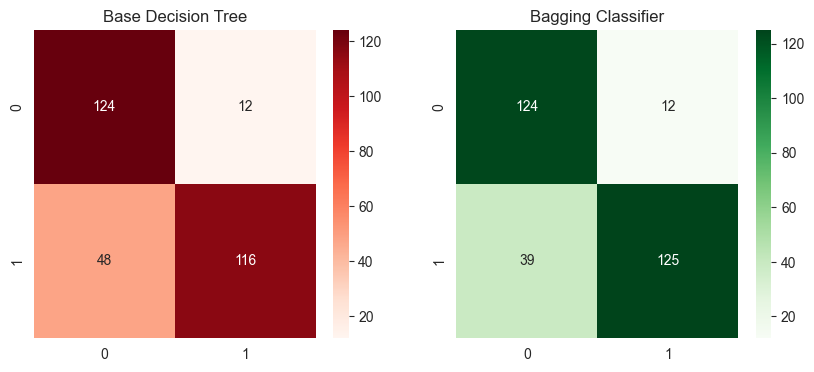

In [12]:
# Visualize confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title("Base Decision Tree")
sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Bagging Classifier")
plt.show()

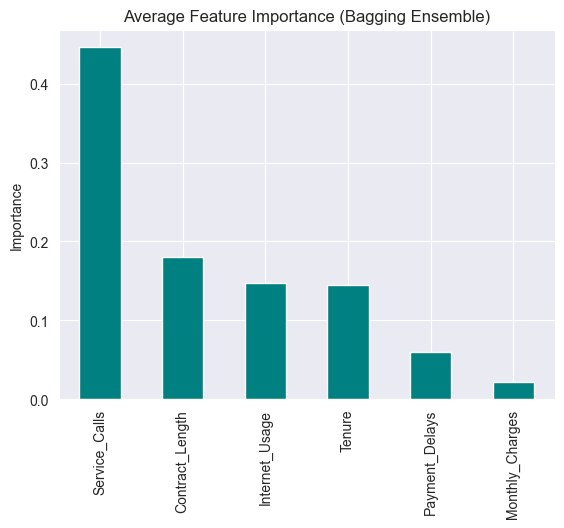

In [13]:
# Feature importance visualization
importances = np.mean([
    tree.feature_importances_ for tree in bagging_model.estimators_
], axis=0)

feature_importance = pd.Series(importances, index=df.columns[:-1]).sort_values(ascending=False)
feature_importance.plot(kind="bar", color="teal")
plt.title("Average Feature Importance (Bagging Ensemble)")
plt.ylabel("Importance")
plt.show()